## Broadband TS spectrum validation against CRIMAC

This notebook demonstrates a minimal workflow for computing broadband target-strength spectra (`TS_spectrum`) with echopype from EK80 FM data.

The results are compared against the CRIMAC reference implementation described in Andersen et al. (2024). The comparison examines intermediate processing steps as well as the final TS spectrum estimates.

Reference implementation:
- Andersen, L. N. et al. (2024). *Quantitative processing of broadband data as implemented in a scientific split-beam echosounder*. Methods in Ecology and Evolution, 15(2), 317–328. https://doi.org/10.1111/2041-210X.14261
- CRIMAC repository: https://github.com/CRIMAC-WP4-Machine-learning/CRIMAC-Raw-To-Svf-TSf

Reference case:

- Raw file: `IMR-D20211215-T143432-TSf.raw`
- Channel: `WBT 747022-15 ES120-7CD_ES`
- CRIMAC ping number: 510
- Python ping index: 509

The notebook follows the processing chain step by step:

- Open the raw EK80 file
- Load the exported CRIMAC reference outputs
- Initialise the EK80 calibration object
- Rebuild the transmit signal and matched filter
- Pulse-compress the complex samples
- Convert pulse-compressed signals to received power
- Reproduce broadband point scattering strength, `Sp`
- Compute split-beam angles
- Identify the calibration sphere target
- Align the matched-filter autocorrelation with the target echo
- Compute the target and matched-filter spectra
- Compute the beam-compensated gain
- Compute the final calibrated `TS(f)`
- Validate the result against the public `compute_TS_spectrum()` API

We start by importing the necessary libraries.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

import echopype as ep

from echopype.calibrate.calibrate_ek import CalibrateEK80
from echopype.calibrate.ek80_complex import (
    get_filter_coeff,
    get_transmit_signal,
)

If the example data are not already available locally, they will be downloaded from the GitHub release asset, verified with a SHA256 checksum, and extracted into the local `example_data/` folder.

In [2]:
from utils.data import fetch_dataset
data_dir = fetch_dataset("ts_spectrum_example_data")

raw_file_TS = data_dir / "IMR-D20211215-T143432-TSf.raw"
ref_file_TS = data_dir / "crimac_tsf_reference_outputs.npz"

Using local dataset: example_data\ts_spectrum_example_data


We convert the raw data to echodata object.

In [3]:
ed_ts = ep.open_raw(raw_file_TS, sonar_model="EK80")
ed_ts

<EchoData: standardized raw data from Internal Memory>
Top-level: contains metadata about the SONAR-netCDF4 file format.
├── Environment: contains information relevant to acoustic propagation through water.
├── Platform: contains information about the platform on which the sonar is installed.
│   └── NMEA: contains information specific to the NMEA protocol.
├── Provenance: contains metadata about how the SONAR-netCDF4 version of the data were obtained.
├── Sonar: contains sonar system metadata and sonar beam groups.
│   └── Beam_group1: contains FM-only or CW-only complex backscatter data and other beam or channel-specific data.
└── Vendor_specific: contains vendor-specific information about the sonar and the data.

In [4]:
print(ed_ts['Sonar']['channel_all'])

<xarray.DataArray 'channel_all' (channel_all: 4)> Size: 416B
array(['WBT 747008-15 ES333-7CD_ES', 'WBT 747015-15 ES70-7CD_ES',
       'WBT 747019-15 ES200-7CD_ES', 'WBT 747022-15 ES120-7CD_ES'],
      dtype='<U26')
Coordinates:
  * channel_all  (channel_all) <U26 416B 'WBT 747008-15 ES333-7CD_ES' ... 'WB...
Attributes:
    long_name:  Vendor channel ID


We select the same ping and frequency as those used by Andersen et al. (2024).

In [5]:
tsf_channel = "WBT 747022-15 ES120-7CD_ES"

# CRIMAC uses 1-based ping numbering.
# Python/xarray uses 0-based indexing.
crimac_ping_number = 510
tsf_ping_index = crimac_ping_number - 1

We initialise a `CalibrateEK80`  object to access the internal calibration data and helper functions used in the step-by-step TS spectrum calculation.

In [6]:
cal_obj = CalibrateEK80(
    ed_ts,
    env_params=None,
    cal_params=None,
    ecs_file=None,
    waveform_mode="BB",
    encode_mode="complex",
)

We then load the reference outputs previously exported from the original CRIMAC processing chain. These results provide the benchmark against which the echopype implementation is compared.

In [7]:
ref_ts = np.load(ref_file_TS)

for k in ref_ts.keys():
    print(k, ref_ts[k].shape, ref_ts[k].dtype)

y_rx_nu (4, 2356) complex128
r_n (2356,) float64
f_m (1000,) float64
alpha_m (1000,) float64
lambda_m (1000,) float64
y_tx_n (3071,) float64
y_mf_n (516,) complex128
y_mf_auto_n (1031,) complex128
tau_eff () float64
y_pc_nu (4, 2356) complex128
y_pc_n (2356,) complex128
p_rx_e_n (2356,) float64
theta_n (2356,) float64
phi_n (2356,) float64
Sp_full_n (2356,) float64
Sp_full_r (2356,) float64
Sp_target_n (168,) float64
Sp_target_r (168,) float64
dum_r (168,) float64
dum_theta (168,) float64
dum_phi (168,) float64
r_t () float64
theta_t () float64
phi_t () float64
y_pc_t_n (168,) complex128
y_mf_auto_red_n (168,) complex128
Y_pc_t_m (1000,) complex128
Y_mf_auto_red_m (1000,) complex128
Y_tilde_pc_t_m (1000,) complex128
P_rx_e_t_m (1000,) float64
g_theta_phi_m (1000,) float64
TS_m (1000,) float64


We define a few helper functions that will be used throughout the validation workflow.

In [8]:
def scalar_param(da, channel=None, ping_idx=None):
    """Select scalar from a possibly channel/ping-dependent DataArray."""
    if channel is not None and "channel" in da.dims:
        da = da.sel(channel=channel)
    if ping_idx is not None and "ping_time" in da.dims:
        da = da.isel(ping_time=ping_idx)
    return float(da)


def db20(x):
    return 20 * np.log10(np.abs(x))


def db10(x):
    return 10 * np.log10(np.abs(x))


def compare_summary(name, ref, ep):
    ref = np.asarray(ref)
    ep = np.asarray(ep)

    n = min(ref.size, ep.size)
    ref = ref.reshape(-1)[:n]
    ep = ep.reshape(-1)[:n]

    diff = ep - ref

    return {
        "variable": name,
        "n": n,
        "CRIMAC mean": np.nanmean(ref),
        "echopype mean": np.nanmean(ep),
        "mean diff": np.nanmean(diff),
        "median diff": np.nanmedian(diff),
        "RMSE": np.sqrt(np.nanmean(diff**2)),
        "max abs diff": np.nanmax(np.abs(diff)),
    }


def compare_curve(
    x_ref,
    y_ref,
    x_ep,
    y_ep,
    title,
    xlabel,
    ylabel,
    xlim=None,
    ylim=None,
):
    plt.figure(figsize=(8, 3.5))
    plt.plot(x_ref, y_ref, label="CRIMAC")
    plt.plot(x_ep, y_ep, "--", label="echopype", alpha=0.85)

    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Rebuild the transmit signal and matched filter

We reconstruct the broadband transmit signal from the EK80 filter coefficients, then compute its matched-filter autocorrelation. This reproduces the signal used by CRIMAC for pulse compression.

In [9]:
tx_coeff = get_filter_coeff(cal_obj.vend)
fs = cal_obj.cal_params["receiver_sampling_frequency"]

tx, tx_time = get_transmit_signal(
    cal_obj.beam,
    tx_coeff,
    cal_obj.waveform_mode,
    fs,
    cal_obj.drop_last_hanning_zero,
)

y_mf_n = tx[tsf_channel]

y_mf_auto_n = np.convolve(
    y_mf_n,
    np.conj(y_mf_n[::-1]),
    mode="full",
) / np.linalg.norm(y_mf_n) ** 2

print("echopype y_mf_n:", y_mf_n.shape)
print("CRIMAC y_mf_n  :", ref_ts["y_mf_n"].shape)

print("echopype y_mf_auto_n:", y_mf_auto_n.shape)
print("CRIMAC y_mf_auto_n  :", ref_ts["y_mf_auto_n"].shape)

echopype y_mf_n: (516,)
CRIMAC y_mf_n  : (516,)
echopype y_mf_auto_n: (1031,)
CRIMAC y_mf_auto_n  : (1031,)


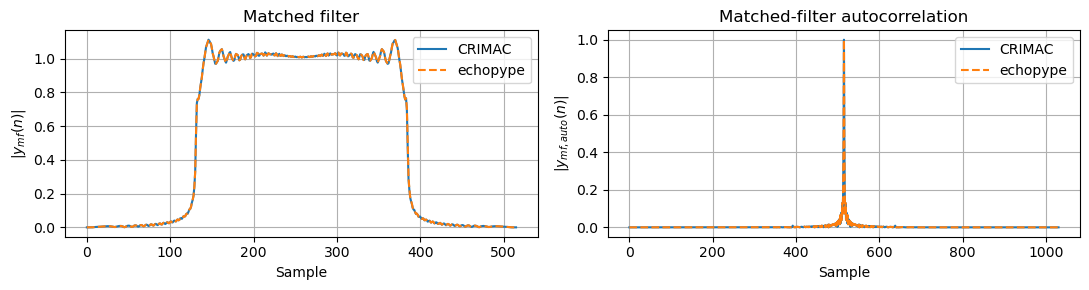

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))

ax[0].plot(np.abs(ref_ts["y_mf_n"]), label="CRIMAC")
ax[0].plot(np.abs(y_mf_n), "--", label="echopype")
ax[0].set_title("Matched filter")
ax[0].set_xlabel("Sample")
ax[0].set_ylabel(r"$|y_{mf}(n)|$")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(np.abs(ref_ts["y_mf_auto_n"]), label="CRIMAC")
ax[1].plot(np.abs(y_mf_auto_n), "--", label="echopype")
ax[1].set_title("Matched-filter autocorrelation")
ax[1].set_xlabel("Sample")
ax[1].set_ylabel(r"$|y_{mf,auto}(n)|$")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

### Apply pulse compression

We apply pulse compression to the complex sector signals using the reconstructed matched filter. The resulting `pc` array contains the pulse-compressed signal for each transducer sector, while `pc_avg` is the sector-averaged pulse-compressed signal used for the TS-spectrum calculation.

In [11]:
from echopype.calibrate.ek80_complex import (
    _get_pulse_compressed_signal,
    _get_average_signal,
)

pc = _get_pulse_compressed_signal(
    beam=cal_obj.beam,
    matched_filter=tx,
)

pc_avg = _get_average_signal(pc)

pc_ping = pc.sel(channel=tsf_channel).isel(ping_time=tsf_ping_index)
pc_avg_ping = pc_avg.sel(channel=tsf_channel).isel(ping_time=tsf_ping_index)

r_ping = (
    cal_obj.range_meter
    .sel(channel=tsf_channel)
    .isel(ping_time=tsf_ping_index)
)

valid = np.isfinite(pc_avg_ping) & np.isfinite(r_ping)

pc_ping = pc_ping.where(valid, drop=True)
pc_avg_ping = pc_avg_ping.where(valid, drop=True)
r_n = r_ping.where(valid, drop=True).values

y_pc_n = pc_avg_ping.values

print("echopype y_pc_n:", y_pc_n.shape)
print("CRIMAC y_pc_n  :", ref_ts["y_pc_n"].shape)
print("echopype r_n   :", r_n.shape)
print("CRIMAC r_n     :", ref_ts["r_n"].shape)

echopype y_pc_n: (2356,)
CRIMAC y_pc_n  : (2356,)
echopype r_n   : (2356,)
CRIMAC r_n     : (2356,)


C:\Users\lloyd\AppData\Local\Temp\ipykernel_13472\1980613090.py:11: RuntimeWarning: divide by zero encountered in log10
  return 20 * np.log10(np.abs(x))


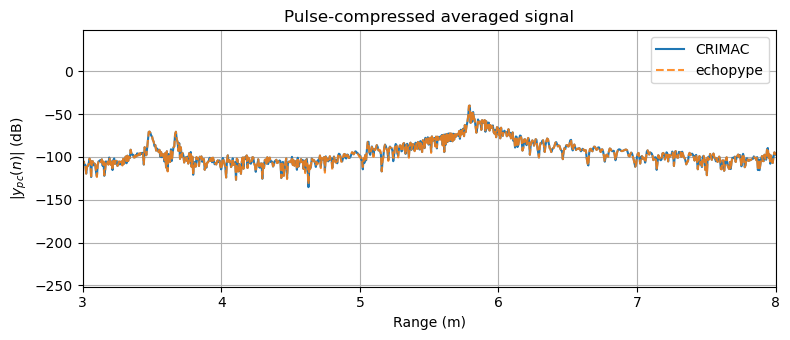

In [12]:
compare_curve(
    ref_ts["r_n"],
    db20(ref_ts["y_pc_n"]),
    r_n,
    db20(y_pc_n),
    title="Pulse-compressed averaged signal",
    xlabel="Range (m)",
    ylabel=r"$|y_{pc}(n)|$ (dB)",
    xlim=(3, 8),
)

check for above that we remove th surface values? (like safe_rang?) or why do we have the warning if not

### Convert pulse-compressed signals to received power

We convert the sector-level pulse-compressed complex signals into received electrical power using the transducer and transceiver impedances. This reproduces the CRIMAC `p_rx_e_n` variable for the selected ping.

In [13]:
z_td_e = scalar_param(
    cal_obj.cal_params["impedance_transducer"],
    tsf_channel,
    tsf_ping_index,
)

z_rx_e = scalar_param(
    cal_obj.cal_params["impedance_transceiver"],
    tsf_channel,
    None,
)

n_beams = cal_obj.beam["beam"].size

from echopype.calibrate.ek80_complex import _compute_power_from_complex_signal

p_rx_e_n = _compute_power_from_complex_signal(
    signal=pc_ping,
    z_et=z_td_e,
    z_er=z_rx_e,
).values

print("z_td_e:", z_td_e)
print("z_rx_e:", z_rx_e)
print("n_beams:", n_beams)

print("echopype p_rx_e_n:", p_rx_e_n.shape)
print("CRIMAC p_rx_e_n  :", ref_ts["p_rx_e_n"].shape)

z_td_e: 75.0
z_rx_e: 5400.0
n_beams: 4
echopype p_rx_e_n: (2356,)
CRIMAC p_rx_e_n  : (2356,)


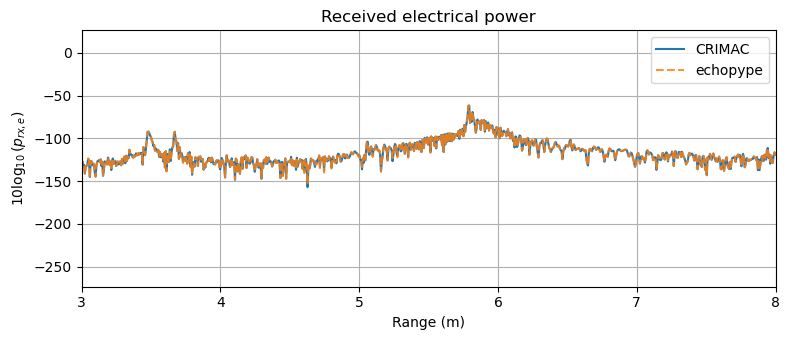

In [14]:
compare_curve(
    ref_ts["r_n"],
    db10(ref_ts["p_rx_e_n"]),
    r_n,
    db10(p_rx_e_n),
    title="Received electrical power",
    xlabel="Range (m)",
    ylabel=r"$10\log_{10}(p_{rx,e})$",
    xlim=(3, 8),
)

### Reproduce the broadband point scattering strength (Sp)

Using the received power, range, and calibration parameters, we reproduce the broadband point scattering strength (`Sp`) calculated by CRIMAC. This quantity is evaluated at the transducer centre frequency and is used to identify candidate single targets before computing the frequency-dependent TS spectrum.

In [15]:
sound_speed = scalar_param(
    cal_obj.env_params["sound_speed"],
    tsf_channel,
    tsf_ping_index,
)

absorption = scalar_param(
    cal_obj.env_params["sound_absorption"],
    tsf_channel,
    tsf_ping_index,
)

transmit_power = scalar_param(
    cal_obj.beam["transmit_power"],
    tsf_channel,
    tsf_ping_index,
)

f_c = scalar_param(
    cal_obj.freq_center,
    tsf_channel,
    tsf_ping_index,
)

lambda_fc = sound_speed / f_c

gain_fc_db = scalar_param(
    cal_obj.cal_params["gain_correction"],
    tsf_channel,
    tsf_ping_index,
)

g_0_fc = 10 ** (gain_fc_db / 10)

r_n_safe = np.where(r_n > 0, r_n, 1e-20)

Sp_n = (
    10 * np.log10(p_rx_e_n)
    + 40 * np.log10(r_n_safe)
    + 2 * absorption * r_n_safe
    - 10 * np.log10(
        transmit_power * lambda_fc**2 * g_0_fc**2 / (16 * np.pi**2)
    )
)

print("sound_speed:", sound_speed)
print("absorption:", absorption)
print("transmit_power:", transmit_power)
print("f_c:", f_c)
print("lambda_fc:", lambda_fc)
print("gain_fc_db:", gain_fc_db)

sound_speed: 1485.4
absorption: 0.03770373022901242
transmit_power: 100.0
f_c: 130000.0
lambda_fc: 0.011426153846153846
gain_fc_db: 28.0375


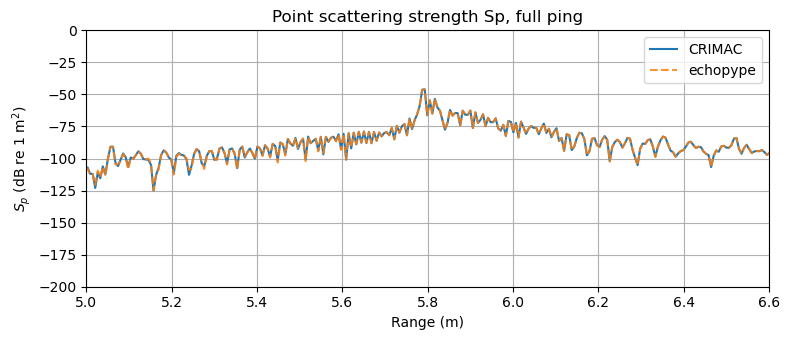

In [16]:
compare_curve(
    ref_ts["Sp_full_r"],
    ref_ts["Sp_full_n"],
    r_n,
    Sp_n,
    title="Point scattering strength Sp, full ping",
    xlabel="Range (m)",
    ylabel=r"$S_p$ (dB re 1 m$^2$)",
    xlim=(5.0, 6.6),
    ylim=(-200, 0),
)

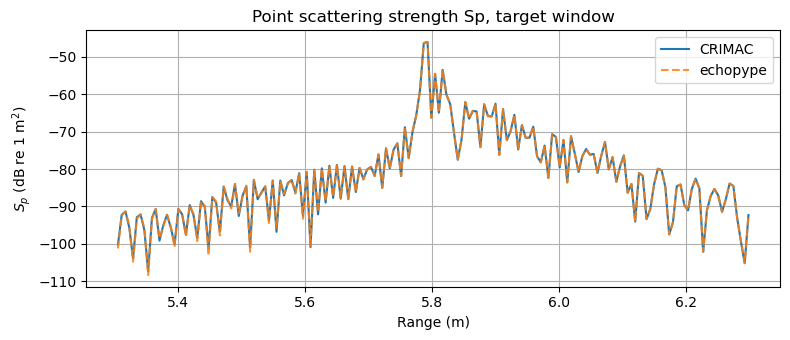

lengths: 168 168
range first/last CRIMAC: 5.30584878660402 6.298095984098836
range first/last manual: 5.3058488 6.298096
Sp target RMSE: 0.3064048011908493
Sp target max: 1.8527138710007023


In [17]:
i0 = int(np.argmin(np.abs(r_n - ref_ts["Sp_target_r"][0])))
i1 = i0 + ref_ts["Sp_target_r"].size

compare_curve(
    ref_ts["Sp_target_r"],
    ref_ts["Sp_target_n"],
    r_n[i0:i1],
    Sp_n[i0:i1],
    title="Point scattering strength Sp, target window",
    xlabel="Range (m)",
    ylabel=r"$S_p$ (dB re 1 m$^2$)",
)

diff = Sp_n[i0:i1] - ref_ts["Sp_target_n"]

print("lengths:", ref_ts["Sp_target_n"].size, Sp_n[i0:i1].size)
print("range first/last CRIMAC:", ref_ts["Sp_target_r"][0], ref_ts["Sp_target_r"][-1])
print("range first/last manual:", r_n[i0], r_n[i1 - 1])
print("Sp target RMSE:", np.sqrt(np.nanmean(diff**2)))
print("Sp target max:", np.nanmax(np.abs(diff)))

why do we have difference in the curves?

In [18]:
diff = Sp_n[i0:i1] - ref_ts["Sp_target_n"]

print("mean:", np.nanmean(diff))
print("median:", np.nanmedian(diff))
print("RMSE:", np.sqrt(np.nanmean(diff**2)))
print("max abs:", np.nanmax(np.abs(diff)))
print("95% abs:", np.nanpercentile(np.abs(diff), 95))
print("99% abs:", np.nanpercentile(np.abs(diff), 99))

imax = np.nanargmax(np.abs(diff))
print("max index:", imax)
print("range:", r_n[i0:i1][imax])
print("CRIMAC:", ref_ts["Sp_target_n"][imax])
print("echopype:", Sp_n[i0:i1][imax])
print("diff:", diff[imax])

mean: -0.03509303154669198
median: -0.005129335564895143
RMSE: 0.3064048011908493
max abs: 1.8527138710007023
95% abs: 0.7342241014215845
99% abs: 1.0939855293269973
max index: 24
range: 5.4484472
CRIMAC: -101.23159919223684
echopype: -103.08431306323754
diff: -1.8527138710007023


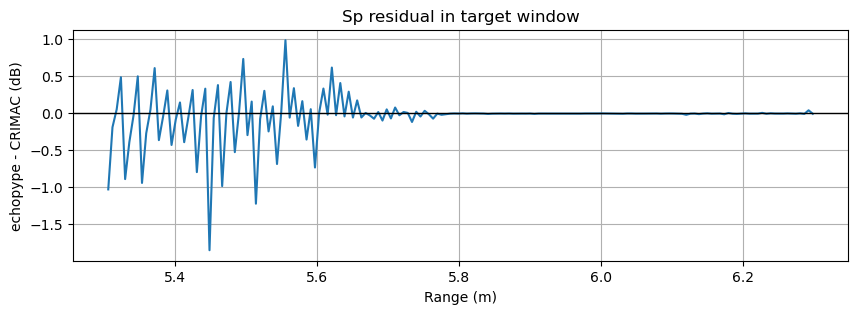

In [19]:
plt.figure(figsize=(10, 3))
plt.plot(r_n[i0:i1], diff)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Range (m)")
plt.ylabel("echopype - CRIMAC (dB)")
plt.title("Sp residual in target window")
plt.grid(True)
plt.show()

### Get split-beam alongship and athwartship angles

For split-beam EK80 data, the target position within the transducer beam is estimated from the phase differences between transducer sectors. Because this example uses FM complex data, the sector-level complex samples are first pulse-compressed, then combined into fore, aft, starboard, and port transducer halves.

The alongship and athwartship angles are then computed following the CRIMAC broadband processing workflow. Phase differences between transducer halves are converted to physical angles using the calibrated angle sensitivities and the inverse-sine relationship described in Andersen et al. (2024). This approach reproduces the reference CRIMAC implementation used to generate the published broadband TS spectrum example.

In [20]:


gamma_alongship = scalar_param(
    cal_obj.cal_params["angle_sensitivity_alongship"],
    tsf_channel,
    tsf_ping_index,
)

gamma_athwartship = scalar_param(
    cal_obj.cal_params["angle_sensitivity_athwartship"],
    tsf_channel,
    tsf_ping_index,
)

from echopype.calibrate.ek80_complex import _get_splitbeam_angles
theta, phi = _get_splitbeam_angles(
    pc=pc_ping,
    gamma_alongship=gamma_alongship,
    gamma_athwartship=gamma_athwartship,
)

print("gamma_alongship:", gamma_alongship)
print("gamma_athwartship:", gamma_athwartship)
print("theta shape:", theta.shape)
print("phi shape:", phi.shape)

gamma_alongship: 24.916666666666664
gamma_athwartship: 24.916666666666664
theta shape: (2356,)
phi shape: (2356,)


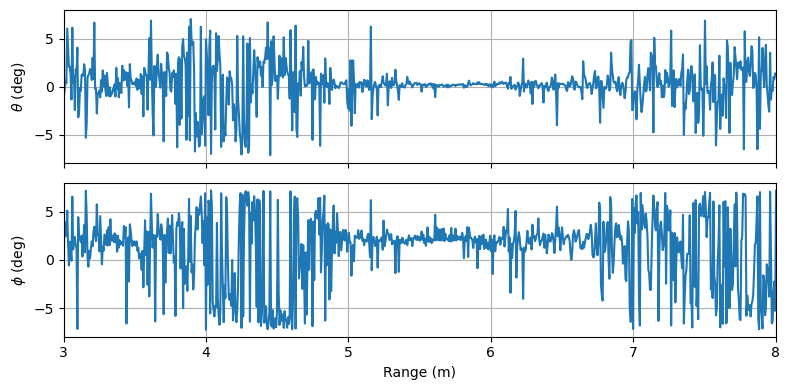

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

ax[0].plot(r_n, theta)
ax[0].set_ylabel(r"$\theta$ (deg)")
ax[0].grid(True)

ax[1].plot(r_n, phi)
ax[1].set_ylabel(r"$\phi$ (deg)")
ax[1].set_xlabel("Range (m)")
ax[1].grid(True)

plt.xlim(3, 8)
plt.tight_layout()
plt.show()

Cmpare with Crimac

theta RMSE: 0.43174450157798355
theta max : 13.11178108969502
phi RMSE  : 0.9274489945255341
phi max   : 14.476222236380444


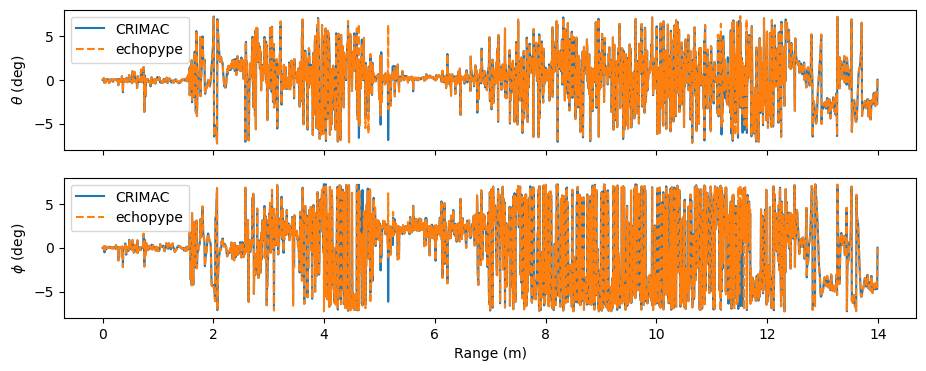

In [22]:
# Compare echopype CRIMAC-style angles against CRIMAC reference angles

theta_np = np.asarray(theta)
phi_np = np.asarray(phi)

n = min(theta_np.size, ref_ts["theta_n"].size)

theta_diff = theta_np[:n] - ref_ts["theta_n"][:n]
phi_diff = phi_np[:n] - ref_ts["phi_n"][:n]

print("theta RMSE:", np.sqrt(np.nanmean(theta_diff**2)))
print("theta max :", np.nanmax(np.abs(theta_diff)))
print("phi RMSE  :", np.sqrt(np.nanmean(phi_diff**2)))
print("phi max   :", np.nanmax(np.abs(phi_diff)))

fig, ax = plt.subplots(2, 1, figsize=(11, 4), sharex=True)

ax[0].plot(r_n[:n], ref_ts["theta_n"][:n], label="CRIMAC")
ax[0].plot(r_n[:n], theta_np[:n], "--", label="echopype")
ax[0].set_ylabel(r"$\theta$ (deg)")
ax[0].legend()

ax[1].plot(r_n[:n], ref_ts["phi_n"][:n], label="CRIMAC")
ax[1].plot(r_n[:n], phi_np[:n], "--", label="echopype")
ax[1].set_ylabel(r"$\phi$ (deg)")
ax[1].set_xlabel("Range (m)")
ax[1].legend()

plt.show()

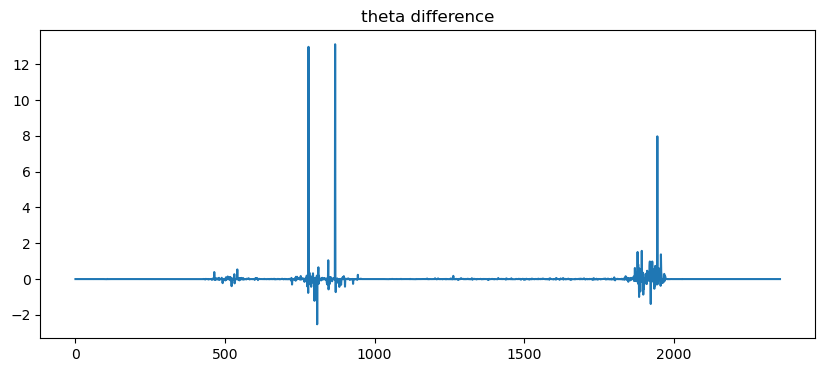

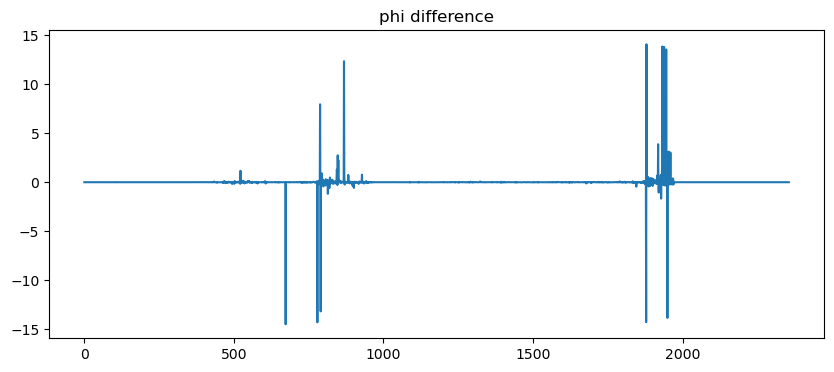

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(theta_np[:n] - ref_ts["theta_n"][:n])
plt.title("theta difference")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(phi_np[:n] - ref_ts["phi_n"][:n])
plt.title("phi difference")
plt.show()

### Compare with echopype split-beam angle helper

The CRIMAC workflow computes physical angles from pulse-compressed transducer halves using an inverse-sine relationship. Echopype also provides a generic split-beam angle helper through the consolidation module. In this section we compare the two implementations to assess whether they produce equivalent alongship and athwartship angle estimates for broadband EK80 data.

In [24]:
from echopype.consolidate.split_beam_angle import get_angle_complex_samples
from echopype.calibrate.ek80_complex import get_filter_coeff

filter_coeff = get_filter_coeff(cal_obj.vend)

pc_params = {
    **filter_coeff,
    "receiver_sampling_frequency": cal_obj.cal_params["receiver_sampling_frequency"],
    "drop_last_hanning_zero": cal_obj.drop_last_hanning_zero,
}

theta_ep, phi_ep = get_angle_complex_samples(
    ds_beam=cal_obj.beam.sel(channel=[tsf_channel]),
    angle_params=cal_obj.cal_params,
    pc_params=pc_params,
)

theta_ep = (
    theta_ep
    .sel(channel=tsf_channel)
    .isel(ping_time=tsf_ping_index)
    .dropna("range_sample")
    .values
)

phi_ep = (
    phi_ep
    .sel(channel=tsf_channel)
    .isel(ping_time=tsf_ping_index)
    .dropna("range_sample")
    .values
)

target_peak_idx = int(np.nanargmin(np.abs(r_n - float(ref_ts["r_t"]))))

print("target_peak_idx:", target_peak_idx)
print("range:", r_n[target_peak_idx], ref_ts["r_t"])

print("CRIMAC theta_t :", ref_ts["theta_t"])
print("echopype theta :", theta_ep[target_peak_idx])
print("theta diff     :", theta_ep[target_peak_idx] - ref_ts["theta_t"])

print("CRIMAC phi_t   :", ref_ts["phi_t"])
print("echopype phi   :", phi_ep[target_peak_idx])
print("phi diff       :", phi_ep[target_peak_idx] - ref_ts["phi_t"])

target_peak_idx: 975
range: 5.79306 5.7930599853739295
CRIMAC theta_t : 0.19805856629305635
echopype theta : 0.2555534398211754
theta diff     : 0.05749487352811905
CRIMAC phi_t   : 2.127909429160737
echopype phi   : 2.1099409547175005
phi diff       : -0.01796847444323646


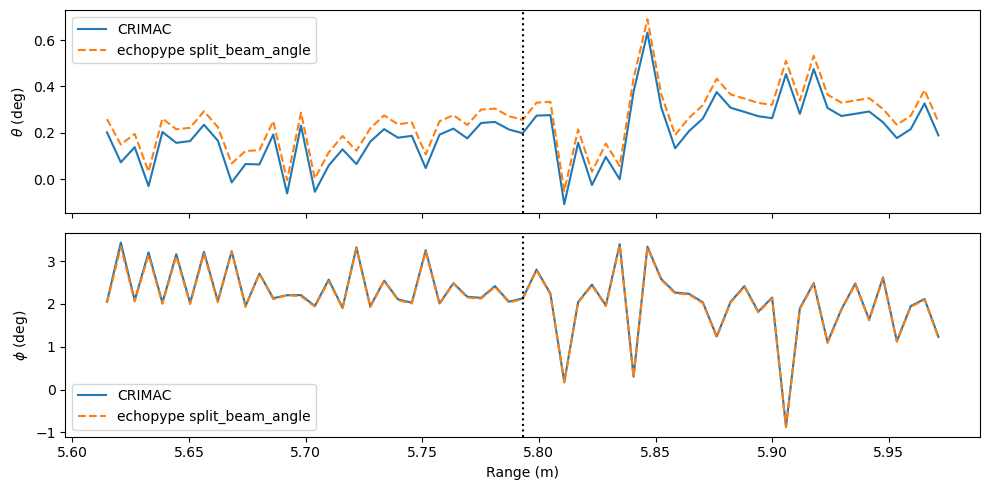

In [25]:
# ============================================================
# Compare CRIMAC and echopype split-beam angles near target
# ============================================================

target_peak_idx = int(np.nanargmin(np.abs(r_n - float(ref_ts["r_t"]))))

i0 = max(0, target_peak_idx - 30)
i1 = min(len(theta_ep), target_peak_idx + 31)

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(
    r_n[i0:i1],
    ref_ts["theta_n"][i0:i1],
    label="CRIMAC",
)
ax[0].plot(
    r_n[i0:i1],
    theta_ep[i0:i1],
    "--",
    label="echopype split_beam_angle",
)
ax[0].axvline(ref_ts["r_t"], color="black", linestyle=":")
ax[0].set_ylabel(r"$\theta$ (deg)")
ax[0].legend()

ax[1].plot(
    r_n[i0:i1],
    ref_ts["phi_n"][i0:i1],
    label="CRIMAC",
)
ax[1].plot(
    r_n[i0:i1],
    phi_ep[i0:i1],
    "--",
    label="echopype split_beam_angle",
)
ax[1].axvline(ref_ts["r_t"], color="black", linestyle=":")
ax[1].set_ylabel(r"$\phi$ (deg)")
ax[1].set_xlabel("Range (m)")
ax[1].legend()

plt.tight_layout()
plt.show()

### Identify the target (calibration sphere) within a range gate

Using the broadband point scattering strength (Sp), we identify the strongest target within a user-defined range gate and extract its range and angular position for subsequent TS-spectrum computation.

In [26]:
def extract_single_target(
    pc_avg: np.ndarray,
    power: np.ndarray,
    theta: np.ndarray,
    phi: np.ndarray,
    range_meter: np.ndarray,
    r0: float,
    r1: float,
    before: float,
    after: float,
):
    """Extract one target echo from a range gate.

    Equivalent to CRIMAC ``singleTarget``.
    """
    idx = np.where((range_meter >= r0) & (range_meter <= r1))

    range_sub = range_meter[idx]
    pc_sub = pc_avg[idx]
    power_sub = power[idx]
    theta_sub = theta[idx]
    phi_sub = phi[idx]

    if range_sub.size == 0:
        raise ValueError("No samples found within target range gate.")

    if np.all(~np.isfinite(power_sub)):
        raise ValueError("No finite power samples found within target range gate.")

    idx_peak = np.nanargmax(power_sub)

    target_range = range_sub[idx_peak]
    target_theta = theta_sub[idx_peak]
    target_phi = phi_sub[idx_peak]

    idx_target = np.where(
        (range_sub >= target_range - before)
        & (range_sub <= target_range + after)
    )

    return (
        target_range,
        target_theta,
        target_phi,
        pc_sub[idx_target],
        power_sub[idx_target],
        theta_sub[idx_target],
        phi_sub[idx_target],
        range_sub[idx_target],
    )

In [27]:
r0 = 5.3
r1 = 6.3
before = 0.5
after = 1.0

(
    r_t,
    theta_t,
    phi_t,
    y_pc_t_n,
    p_rx_t_n,
    dum_theta,
    dum_phi,
    dum_r,
) = extract_single_target(
    pc_avg=y_pc_n,
    power=p_rx_e_n,
    theta=theta,
    phi=phi,
    range_meter=r_n,
    r0=r0,
    r1=r1,
    before=before,
    after=after,
)

print("CRIMAC r_t    :", ref_ts["r_t"])
print("echopype r_t  :", r_t)

print("CRIMAC theta_t:", ref_ts["theta_t"])
print("echopype theta:", theta_t)

print("CRIMAC phi_t  :", ref_ts["phi_t"])
print("echopype phi  :", phi_t)

print("Target samples CRIMAC :", ref_ts["y_pc_t_n"].shape)
print("Target samples echopype:", y_pc_t_n.shape)

CRIMAC r_t    : 5.7930599853739295
echopype r_t  : 5.79306
CRIMAC theta_t: 0.19805856629305635
echopype theta: <xarray.DataArray 'angle_alongship' ()> Size: 8B
array(0.19805383)
Coordinates:
    channel       <U26 104B 'WBT 747022-15 ES120-7CD_ES'
    ping_time     datetime64[ns] 8B 2021-12-15T14:36:42.927639
    range_sample  int64 8B 975
CRIMAC phi_t  : 2.127909429160737
echopype phi  : <xarray.DataArray 'angle_athwartship' ()> Size: 8B
array(2.12793011)
Coordinates:
    channel       <U26 104B 'WBT 747022-15 ES120-7CD_ES'
    ping_time     datetime64[ns] 8B 2021-12-15T14:36:42.927639
    range_sample  int64 8B 975
Target samples CRIMAC : (168,)
Target samples echopype: (168,)


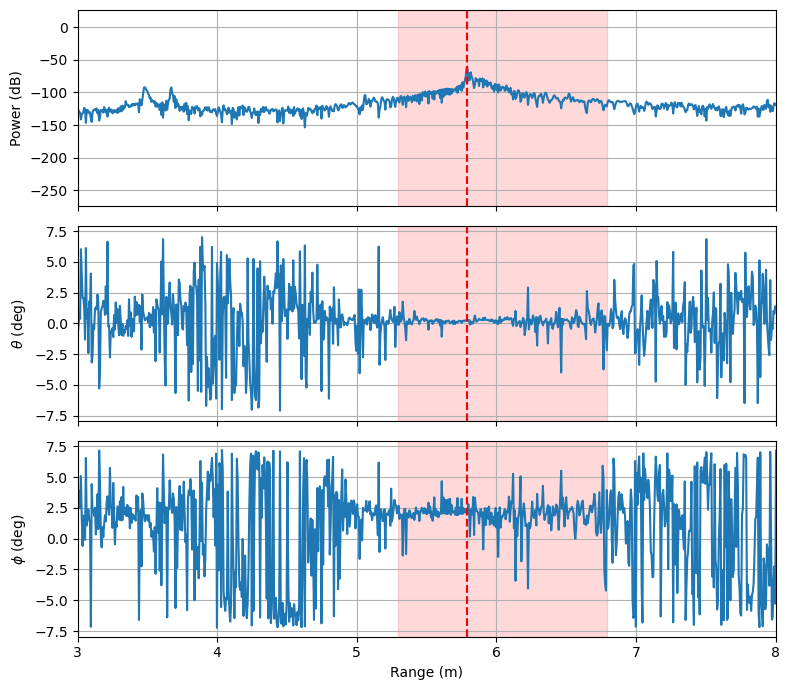

In [28]:
fig, ax = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

ax[0].plot(r_n, db10(p_rx_e_n))
ax[0].axvline(r_t, color="red", linestyle="--")
ax[0].axvspan(r_t - before, r_t + after, color="red", alpha=0.15)
ax[0].set_ylabel("Power (dB)")
ax[0].grid(True)

ax[1].plot(r_n, theta)
ax[1].axvline(r_t, color="red", linestyle="--")
ax[1].axvspan(r_t - before, r_t + after, color="red", alpha=0.15)
ax[1].set_ylabel(r"$\theta$ (deg)")
ax[1].grid(True)

ax[2].plot(r_n, phi)
ax[2].axvline(r_t, color="red", linestyle="--")
ax[2].axvspan(r_t - before, r_t + after, color="red", alpha=0.15)
ax[2].set_ylabel(r"$\phi$ (deg)")
ax[2].set_xlabel("Range (m)")
ax[2].grid(True)

plt.xlim(3, 8)
plt.tight_layout()
plt.show()

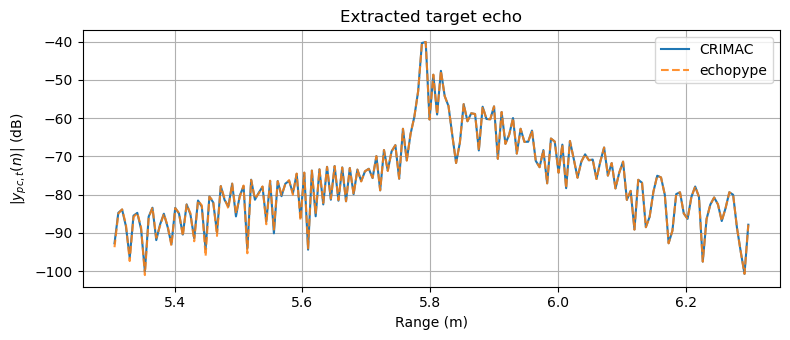

In [29]:
compare_curve(
    ref_ts["dum_r"],
    db20(ref_ts["y_pc_t_n"]),
    dum_r,
    db20(y_pc_t_n),
    title="Extracted target echo",
    xlabel="Range (m)",
    ylabel=r"$|y_{pc,t}(n)|$ (dB)",
)

### Align the matched-filter autocorrelation with the extracted target echo

The matched-filter autocorrelation is centred on the extracted target echo and reduced to the same support. This aligned autocorrelation is required for the subsequent frequency-domain TS-spectrum calculation.

In [30]:
from echopype.calibrate.ek80_complex import _align_autocorrelation
y_mf_auto_red_n = _align_autocorrelation(
    mf_auto=y_mf_auto_n,
    pc_target=y_pc_t_n,
)

print("echopype y_mf_auto_red_n:", y_mf_auto_red_n.shape)
print("CRIMAC y_mf_auto_red_n  :", ref_ts["y_mf_auto_red_n"].shape)

echopype y_mf_auto_red_n: (168,)
CRIMAC y_mf_auto_red_n  : (168,)


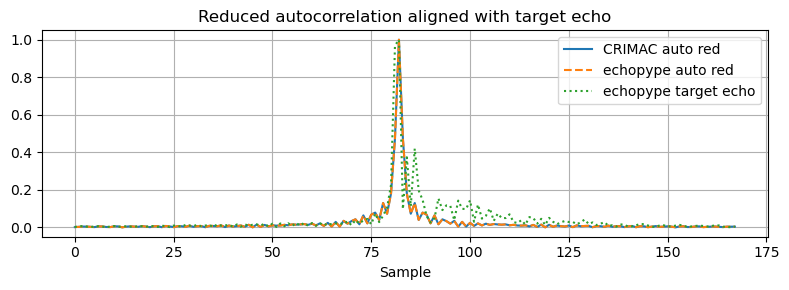

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))

ax.plot(
    np.abs(ref_ts["y_mf_auto_red_n"]) / np.nanmax(np.abs(ref_ts["y_mf_auto_red_n"])),
    label="CRIMAC auto red",
)
ax.plot(
    np.abs(y_mf_auto_red_n) / np.nanmax(np.abs(y_mf_auto_red_n)),
    "--",
    label="echopype auto red",
)

ax.plot(
    np.abs(y_pc_t_n) / np.nanmax(np.abs(y_pc_t_n)),
    ":",
    label="echopype target echo",
)

ax.set_title("Reduced autocorrelation aligned with target echo")
ax.set_xlabel("Sample")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

### Compute the target and matched-filter spectra in the frequency domain

In [32]:
print("CRIMAC y_pc_t_n size:", ref_ts["y_pc_t_n"].size)
print("manual y_pc_t_n size:", y_pc_t_n.size)

print("RMSE abs:", np.sqrt(np.nanmean((np.abs(y_pc_t_n) - np.abs(ref_ts["y_pc_t_n"]))**2)))
print("max abs diff abs:", np.nanmax(np.abs(np.abs(y_pc_t_n) - np.abs(ref_ts["y_pc_t_n"]))))

print("first 5 CRIMAC abs:", np.abs(ref_ts["y_pc_t_n"][:5]))
print("first 5 manual abs:", np.abs(y_pc_t_n[:5]))

CRIMAC y_pc_t_n size: 168
manual y_pc_t_n size: 168
RMSE abs: 1.5463490954583334e-06
max abs diff abs: 4.604589062179967e-06
first 5 CRIMAC abs: [2.31729706e-05 5.79533997e-05 6.39145546e-05 3.88268996e-05
 1.50424514e-05]
first 5 manual abs: [2.05866846e-05 5.67176606e-05 6.43208689e-05 4.10774966e-05
 1.35798767e-05]


In [33]:
sample_interval = scalar_param(
    cal_obj.beam["sample_interval"],
    tsf_channel,
    tsf_ping_index,
)

f_start = scalar_param(
    cal_obj.beam["transmit_frequency_start"],
    tsf_channel,
    tsf_ping_index,
)

f_stop = scalar_param(
    cal_obj.beam["transmit_frequency_stop"],
    tsf_channel,
    tsf_ping_index,
)

fs_dec = 1 / sample_interval

# Use CRIMAC frequency grid exactly for manual validation.
f_m = ref_ts["f_m"]
n_f_points = f_m.size

from echopype.calibrate.ek80_complex import _compute_ts_spectrum
Y_pc_t_m, Y_mf_auto_red_m, Y_tilde_pc_t_m = _compute_ts_spectrum(
    pc_target=y_pc_t_n,
    mf_auto_red=y_mf_auto_red_n,
    NFFT=n_f_points,
    frequency=f_m,
    fs_dec=fs_dec,
)

print("sample_interval:", sample_interval)
print("fs_dec:", fs_dec)
print("f_start/f_stop:", f_start, f_stop)
print("f_m shape:", f_m.shape)
print("Y_pc_t_m:", Y_pc_t_m.shape)
print("Y_mf_auto_red_m:", Y_mf_auto_red_m.shape)
print("Y_tilde_pc_t_m:", Y_tilde_pc_t_m.shape)

sample_interval: 8e-06
fs_dec: 125000.0
f_start/f_stop: 90000.0 170000.0
f_m shape: (1000,)
Y_pc_t_m: (1000,)
Y_mf_auto_red_m: (1000,)
Y_tilde_pc_t_m: (1000,)


The figure below shows the DFT of the extracted target echo. This spectrum contains both the target response and the frequency characteristics of the transmitted pulse.

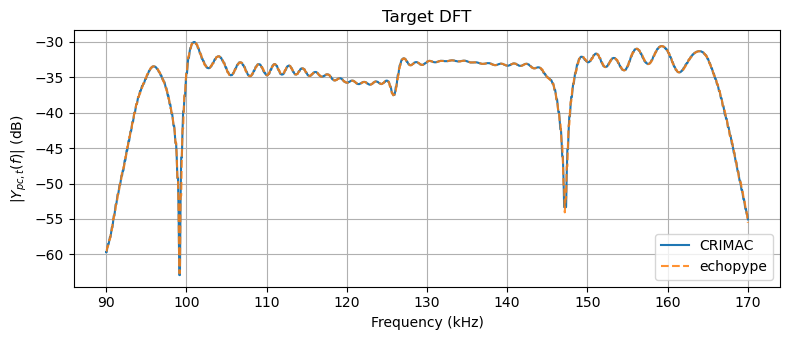

In [34]:
compare_curve(
    ref_ts["f_m"] / 1000,
    db20(ref_ts["Y_pc_t_m"]),
    f_m / 1000,
    db20(Y_pc_t_m),
    title="Target DFT",
    xlabel="Frequency (kHz)",
    ylabel=r"$|Y_{pc,t}(f)|$ (dB)",
)

The figure below shows the DFT of the aligned matched-filter autocorrelation. This spectrum represents the frequency response of the transmitted signal used for normalisation.

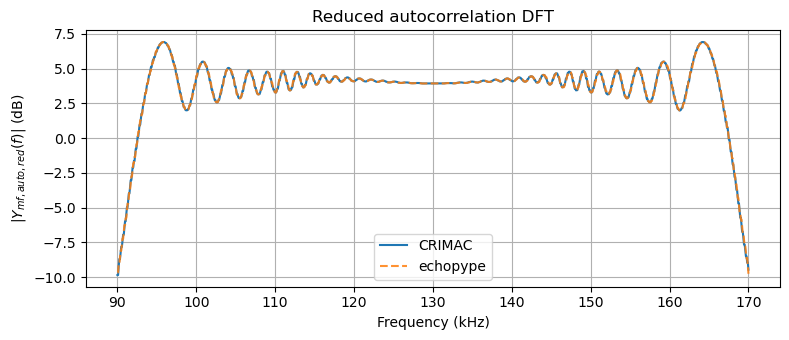

In [35]:
compare_curve(
    ref_ts["f_m"] / 1000,
    db20(ref_ts["Y_mf_auto_red_m"]),
    f_m / 1000,
    db20(Y_mf_auto_red_m),
    title="Reduced autocorrelation DFT",
    xlabel="Frequency (kHz)",
    ylabel=r"$|Y_{mf,auto,red}(f)|$ (dB)",
)

The figure below shows the normalised target spectrum obtained after dividing the target spectrum by the matched-filter spectrum. This quantity forms the basis of the broadband TS-spectrum calculation.

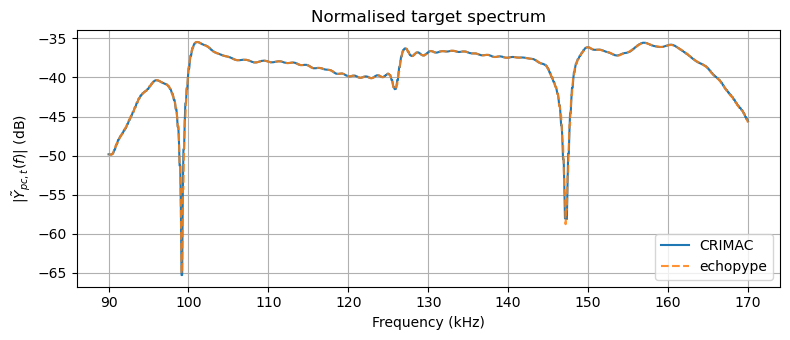

In [36]:
compare_curve(
    ref_ts["f_m"] / 1000,
    db20(ref_ts["Y_tilde_pc_t_m"]),
    f_m / 1000,
    db20(Y_tilde_pc_t_m),
    title="Normalised target spectrum",
    xlabel="Frequency (kHz)",
    ylabel=r"$|\tilde{Y}_{pc,t}(f)|$ (dB)",
)

### Convert the normalised target spectrum to received electrical power

We convert the normalised target spectrum into a frequency-dependent received electrical power spectrum using the transducer and transceiver impedances. This reproduces the CRIMAC P_rx_e_t_m variable used in the final TS-spectrum calculation.

In [37]:
from echopype.calibrate.ek80_complex import _compute_ts_spectrum_power
P_rx_e_t_m = _compute_ts_spectrum_power(
    normalized_spectrum=Y_tilde_pc_t_m,
    n_beams=n_beams,
    z_et=z_td_e,
    z_er=z_rx_e,
)

print("echopype P_rx_e_t_m:", P_rx_e_t_m.shape)
print("CRIMAC P_rx_e_t_m  :", ref_ts["P_rx_e_t_m"].shape)

echopype P_rx_e_t_m: (1000,)
CRIMAC P_rx_e_t_m  : (1000,)


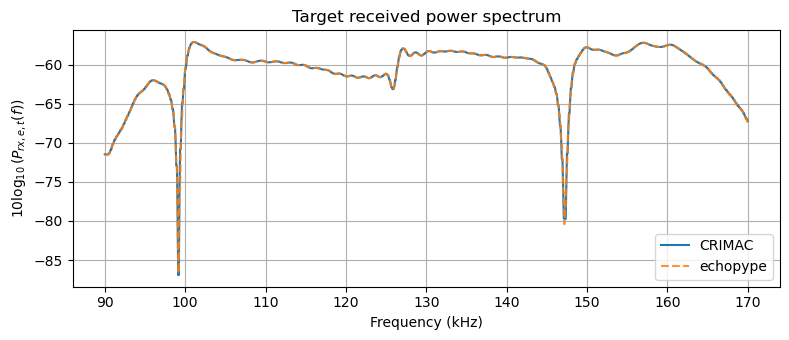

In [38]:
compare_curve(
    ref_ts["f_m"] / 1000,
    db10(ref_ts["P_rx_e_t_m"]),
    f_m / 1000,
    db10(P_rx_e_t_m),
    title="Target received power spectrum",
    xlabel="Frequency (kHz)",
    ylabel=r"$10\log_{10}(P_{rx,e,t}(f))$",
)

### Compute the frequency-dependent beam compensation at the target location

Using the target range angles (θ, φ), we compute the frequency-dependent beam-compensated gain. This correction accounts for the target's off-axis position within the acoustic beam and is required for the final TS-spectrum calculation.

In [40]:
g_theta_phi_m = cal_obj._get_beam_compensated_gain(
    channel=tsf_channel,
    theta=float(theta_t),
    phi=float(phi_t),
    frequency=np.asarray(f_m),
)

print("echopype g_theta_phi_m:", g_theta_phi_m.shape)
print("CRIMAC g_theta_phi_m  :", ref_ts["g_theta_phi_m"].shape)

echopype g_theta_phi_m: (1000,)
CRIMAC g_theta_phi_m  : (1000,)


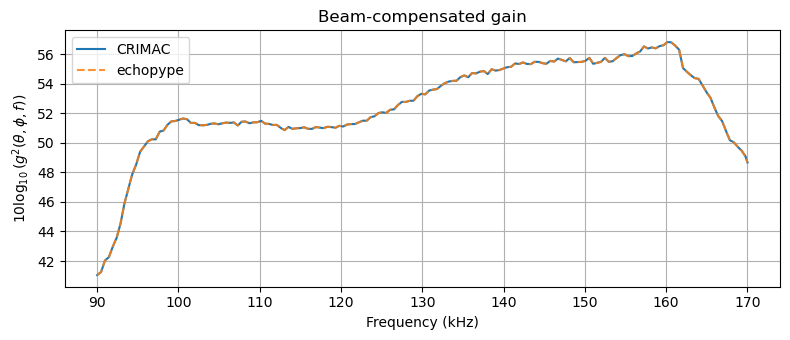

In [41]:
compare_curve(
    ref_ts["f_m"] / 1000,
    10 * np.log10(ref_ts["g_theta_phi_m"] ** 2),
    f_m / 1000,
    10 * np.log10(g_theta_phi_m ** 2),
    title="Beam-compensated gain",
    xlabel="Frequency (kHz)",
    ylabel=r"$10\log_{10}(g^2(\theta,\phi,f))$",
)

### Compute the calibrated TS spectrum, TS(f)

Using the received power spectrum, target range, beam-compensated gain, and acoustic calibration parameters, we compute the final calibrated target strength spectrum TS(f), following the formulation described by Andersen et al. (2024).

In [42]:
from echopype.utils import uwa

absorption_f = uwa.calc_absorption(
    frequency=f_m,
    temperature=float(scalar_param(cal_obj.env_params["temperature"], tsf_channel, tsf_ping_index)),
    salinity=float(scalar_param(cal_obj.env_params["salinity"], tsf_channel, tsf_ping_index)),
    pressure=float(scalar_param(cal_obj.env_params["pressure"], tsf_channel, tsf_ping_index)),
    pH=float(scalar_param(cal_obj.env_params["pH"], tsf_channel, tsf_ping_index)),
    sound_speed=sound_speed,
    formula_source="FG",
)

print("scalar absorption:", absorption)
print("CRIMAC alpha_m min/max:", ref_ts["alpha_m"].min(), ref_ts["alpha_m"].max())
print("echopype absorption_f min/max:", absorption_f.min(), absorption_f.max())
print("max abs alpha diff:", np.max(np.abs(absorption_f - ref_ts["alpha_m"])))

scalar absorption: 0.03770373022901242
CRIMAC alpha_m min/max: 0.02804324195086584 0.04521493514355129
echopype absorption_f min/max: 0.02804324168412123 0.04521493476510025
max abs alpha diff: 3.7845103439959615e-10


In [43]:
from echopype.calibrate.ek80_complex import _compute_ts_spectrum_calibrated
TS_m = _compute_ts_spectrum_calibrated(
    power_spectrum=P_rx_e_t_m,
    target_range=r_t,
    frequency=f_m,
    sound_speed=sound_speed,
    absorption_f=absorption_f,
    transmit_power=transmit_power,
    gain_f=g_theta_phi_m,
)

print("echopype TS_m:", TS_m.shape)
print("CRIMAC TS_m  :", ref_ts["TS_m"].shape)

echopype TS_m: (1000,)
CRIMAC TS_m  : (1000,)


In [44]:
print(ref_ts["alpha_m"].shape)
print(ref_ts["alpha_m"][:10])
print(ref_ts["alpha_m"].min(), ref_ts["alpha_m"].max())

(1000,)
[0.02804324 0.02806629 0.02808933 0.02811234 0.02813534 0.02815831
 0.02818127 0.02820421 0.02822714 0.02825004]
0.02804324195086584 0.04521493514355129


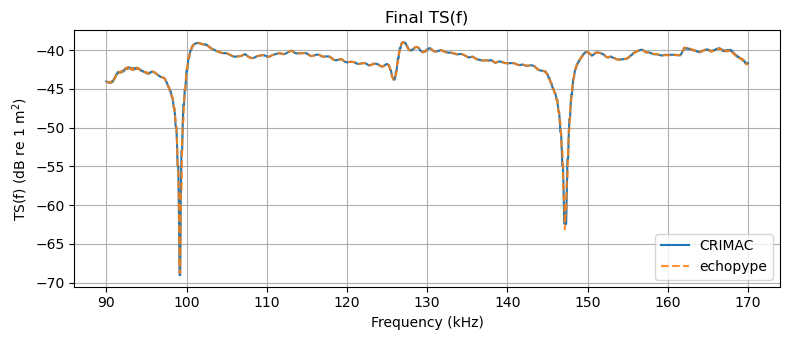

In [45]:
compare_curve(
    ref_ts["f_m"] / 1000,
    ref_ts["TS_m"],
    f_m / 1000,
    TS_m,
    title="Final TS(f)",
    xlabel="Frequency (kHz)",
    ylabel=r"TS(f) (dB re 1 m$^2$)",
)

### Reproduce the Andersen et al. (2024) Figure 7 diagnostic panel

We reproduce a Figure 7-style diagnostic panel from Andersen et al. (2024) using the echopype implementation. The panels show the target spectrum, matched-filter autocorrelation spectrum, normalised target spectrum, beam-compensated gain, and final calibrated TS spectrum.

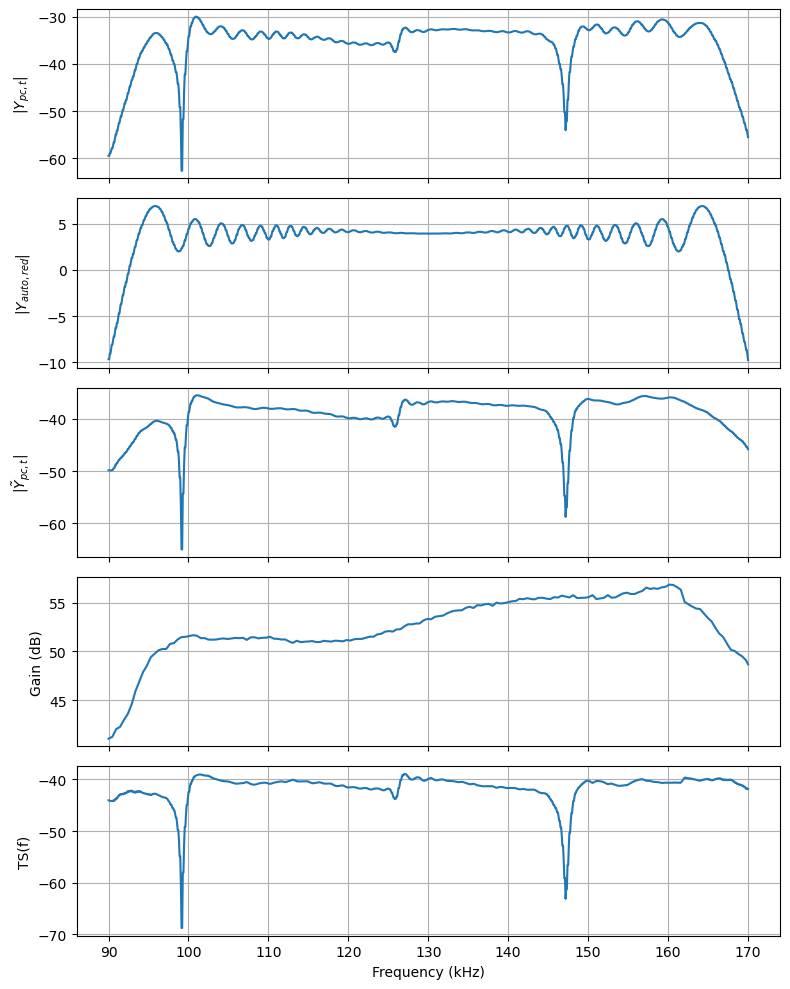

In [46]:
fig, ax = plt.subplots(5, 1, figsize=(8, 10), sharex=True)

ax[0].plot(f_m / 1000, db20(Y_pc_t_m))
ax[0].set_ylabel(r"$|Y_{pc,t}|$")

ax[1].plot(f_m / 1000, db20(Y_mf_auto_red_m))
ax[1].set_ylabel(r"$|Y_{auto,red}|$")

ax[2].plot(f_m / 1000, db20(Y_tilde_pc_t_m))
ax[2].set_ylabel(r"$|\tilde{Y}_{pc,t}|$")

ax[3].plot(f_m / 1000, 10 * np.log10(g_theta_phi_m**2))
ax[3].set_ylabel("Gain (dB)")

ax[4].plot(f_m / 1000, TS_m)
ax[4].set_ylabel("TS(f)")
ax[4].set_xlabel("Frequency (kHz)")

for a in ax:
    a.grid(True)

plt.tight_layout()
plt.show()

### Summary of differences between CRIMAC and echopype processing steps

The table below summarises the differences between corresponding variables computed by CRIMAC and echopype at each stage of the TS-spectrum workflow.

tmp

In [47]:
print(ref_ts.files)

['y_rx_nu', 'r_n', 'f_m', 'alpha_m', 'lambda_m', 'y_tx_n', 'y_mf_n', 'y_mf_auto_n', 'tau_eff', 'y_pc_nu', 'y_pc_n', 'p_rx_e_n', 'theta_n', 'phi_n', 'Sp_full_n', 'Sp_full_r', 'Sp_target_n', 'Sp_target_r', 'dum_r', 'dum_theta', 'dum_phi', 'r_t', 'theta_t', 'phi_t', 'y_pc_t_n', 'y_mf_auto_red_n', 'Y_pc_t_m', 'Y_mf_auto_red_m', 'Y_tilde_pc_t_m', 'P_rx_e_t_m', 'g_theta_phi_m', 'TS_m']


In [48]:
checks = [
    ("y_pc_n abs", np.abs(ref_ts["y_pc_n"]), np.abs(y_pc_n)),
    ("p_rx_e_n dB", db10(ref_ts["p_rx_e_n"]), db10(p_rx_e_n)),
    ("Sp_full_n dB", ref_ts["Sp_full_n"], Sp_n),
    ("r_t", np.array([ref_ts["r_t"]]), np.array([r_t])),
    ("theta_t", np.array([ref_ts["theta_t"]]), np.array([theta_t])),
    ("phi_t", np.array([ref_ts["phi_t"]]), np.array([phi_t])),
    ("y_pc_t_n abs", np.abs(ref_ts["y_pc_t_n"]), np.abs(y_pc_t_n)),
    ("y_mf_auto_red_n abs", np.abs(ref_ts["y_mf_auto_red_n"]), np.abs(y_mf_auto_red_n)),
    ("Y_pc_t_m dB", db20(ref_ts["Y_pc_t_m"]), db20(Y_pc_t_m)),
    ("Y_mf_auto_red_m dB", db20(ref_ts["Y_mf_auto_red_m"]), db20(Y_mf_auto_red_m)),
    ("Y_tilde_pc_t_m dB", db20(ref_ts["Y_tilde_pc_t_m"]), db20(Y_tilde_pc_t_m)),
    ("P_rx_e_t_m dB", db10(ref_ts["P_rx_e_t_m"]), db10(P_rx_e_t_m)),
    ("g_theta_phi_m dB", db10(ref_ts["g_theta_phi_m"]), db10(g_theta_phi_m)),
    ("alpha_m", ref_ts["alpha_m"], absorption_f),
    ("TS_m", ref_ts["TS_m"], TS_m),
]

tol = 1e-6

for name, ref, val in checks:
    ref = np.asarray(ref).reshape(-1)
    val = np.asarray(val).reshape(-1)

    n = min(ref.size, val.size)
    diff = val[:n] - ref[:n]

    max_abs = np.nanmax(np.abs(diff))
    rmse = np.sqrt(np.nanmean(diff**2))

    print(f"{name}: RMSE={rmse:.6g}, max_abs={max_abs:.6g}")

    if max_abs > tol:
        idx = int(np.nanargmax(np.abs(diff)))
        print("\nFIRST DIFFERENCE ABOVE TOLERANCE")
        print("variable:", name)
        print("index:", idx)
        print("CRIMAC:", ref[idx])
        print("echopype/manual:", val[idx])
        print("diff:", diff[idx])
        break

y_pc_n abs: RMSE=0.000203375, max_abs=0.00662722

FIRST DIFFERENCE ABOVE TOLERANCE
variable: y_pc_n abs
index: 1
CRIMAC: 8.244825873734117
echopype/manual: 8.251453096905179
diff: 0.006627223171062013


end tmp

In [49]:
rows = []

rows.append(compare_summary(
    "y_mf_n abs",
    np.abs(ref_ts["y_mf_n"]),
    np.abs(y_mf_n),
))

rows.append(compare_summary(
    "y_mf_auto_n abs",
    np.abs(ref_ts["y_mf_auto_n"]),
    np.abs(y_mf_auto_n),
))

rows.append(compare_summary(
    "y_pc_n abs",
    np.abs(ref_ts["y_pc_n"]),
    np.abs(y_pc_n),
))

rows.append(compare_summary(
    "p_rx_e_n dB",
    db10(ref_ts["p_rx_e_n"]),
    db10(p_rx_e_n),
))

rows.append(compare_summary(
    "Sp_full_n dB",
    ref_ts["Sp_full_n"],
    Sp_n,
))

## target-windows
target_mask = (
    (r_n >= ref_ts["Sp_target_r"].min())
    & (r_n <= ref_ts["Sp_target_r"].max())
)

rows.append(compare_summary(
    "Sp_target_n dB",
    ref_ts["Sp_target_n"],
    Sp_n[target_mask],
))
##

rows.append(compare_summary(
    "y_pc_t_n abs",
    np.abs(ref_ts["y_pc_t_n"]),
    np.abs(y_pc_t_n),
))

rows.append(compare_summary(
    "y_mf_auto_red_n abs",
    np.abs(ref_ts["y_mf_auto_red_n"]),
    np.abs(y_mf_auto_red_n),
))

rows.append(compare_summary(
    "Y_pc_t_m dB",
    db20(ref_ts["Y_pc_t_m"]),
    db20(Y_pc_t_m),
))

rows.append(compare_summary(
    "Y_mf_auto_red_m dB",
    db20(ref_ts["Y_mf_auto_red_m"]),
    db20(Y_mf_auto_red_m),
))

rows.append(compare_summary(
    "Y_tilde_pc_t_m dB",
    db20(ref_ts["Y_tilde_pc_t_m"]),
    db20(Y_tilde_pc_t_m),
))

rows.append(compare_summary(
    "P_rx_e_t_m dB",
    db10(ref_ts["P_rx_e_t_m"]),
    db10(P_rx_e_t_m),
))

rows.append(compare_summary(
    "g_theta_phi_m dB",
    10 * np.log10(ref_ts["g_theta_phi_m"] ** 2),
    10 * np.log10(g_theta_phi_m ** 2),
))

rows.append(compare_summary(
    "TS_m dB",
    ref_ts["TS_m"],
    TS_m,
))

summary = pd.DataFrame(rows)
summary

,variable,n,CRIMAC mean,echopype mean,mean diff,median diff,RMSE,max abs diff
0,y_mf_n abs,516,0.509469,0.509642,1.729508e-04,1.301043e-17,0.001248,0.021871
1,y_mf_auto_n abs,1031,0.004699,0.004695,-3.954363e-06,-6.732322e-15,0.000098,0.000350
2,y_pc_n abs,2356,0.079082,0.079071,-1.070651e-05,-1.008762e-08,0.000203,0.006627
3,p_rx_e_n dB,2356,-106.347106,-106.345857,1.248776e-03,-2.469640e-03,0.387861,8.330394
4,Sp_full_n dB,2356,-92.918309,-92.919339,-1.029862e-03,-4.748281e-03,0.387860,8.332673
5,Sp_target_n dB,167,-82.034552,-82.069809,-3.525722e-02,-5.111712e-03,0.307320,1.852714
6,y_pc_t_n abs,168,0.000436,0.000436,-1.777090e-07,-7.647879e-08,0.000002,0.000005
7,y_mf_auto_red_n abs,168,0.027249,0.027238,-1.024769e-05,-1.586508e-05,0.000211,0.000350
8,Y_pc_t_m dB,1000,-35.450622,-35.448239,2.382618e-03,-2.111098e-03,0.288531,5.399668
9,Y_mf_auto_red_m dB,1000,3.567061,3.570432,3.371336e-03,-1.389353e-03,0.095777,0.455695


## 18. Public API check: compute_TS_spectrum

This validates that the public API returns the same TS spectrum product as the manual helper-chain above.

The workflow is now:

```text
compute_Sp()
→ simple target detection using Sp + split-beam angles
→ point_locations
→ compute_TS_spectrum(point_locations=...)
```

### Reproduce the TS spectrum using the public API

The previous sections reproduced the CRIMAC processing chain step-by-step using internal helper functions. In practice, users can obtain the same TS-spectrum product directly through the public API.

Before calling `compute_TS_spectrum()`, we first need to provide target locations. Here, we use the public `compute_Sp()` output to detect the strongest target within the expected calibration-sphere range gate for each ping. For each detected target, we store the ping time, channel, target range, split-beam angles, and target-window limits in a table that will be passed to `compute_TS_spectrum()`.

**This detection step is intentionally simple and is only used here to generate `point_locations` for validating the TS-spectrum API.**

In [51]:
target_rows = []

ds_Sp = ep.calibrate.compute_Sp(
    echodata=ed_ts,
    waveform_mode="BB",
    encode_mode="complex",
)

print("Available Sp channels:", ds_Sp["channel"].values)
print("Selected channel:", tsf_channel)

sp_ch = ds_Sp["Sp"].sel(channel=tsf_channel)

tx_coeff = get_filter_coeff(cal_obj.vend)
fs = cal_obj.cal_params["receiver_sampling_frequency"]

matched_filter, _ = get_transmit_signal(
    cal_obj.beam,
    tx_coeff,
    cal_obj.waveform_mode,
    fs,
    cal_obj.drop_last_hanning_zero,
)

pc = _get_pulse_compressed_signal(
    beam=cal_obj.beam,
    matched_filter=matched_filter,
)

pc_ch = pc.sel(channel=tsf_channel)
range_ch = cal_obj.range_meter.sel(channel=tsf_channel)

for ping_idx in range(sp_ch.sizes["ping_time"]):
    pc_ping_i = pc_ch.isel(ping_time=ping_idx)
    sp_i = sp_ch.isel(ping_time=ping_idx)
    r_i = range_ch.isel(ping_time=ping_idx)

    valid = np.isfinite(sp_i) & np.isfinite(r_i)

    if not bool(valid.any()):
        continue

    pc_ping_i = pc_ping_i.where(valid, drop=True)
    sp_i = sp_i.where(valid, drop=True).values
    r_i = r_i.where(valid, drop=True).values

    gamma_theta_i = scalar_param(
        cal_obj.cal_params["angle_sensitivity_alongship"],
        tsf_channel,
        ping_idx,
    )

    gamma_phi_i = scalar_param(
        cal_obj.cal_params["angle_sensitivity_athwartship"],
        tsf_channel,
        ping_idx,
    )

    theta_i, phi_i = _get_splitbeam_angles(
        pc=pc_ping_i,
        gamma_alongship=gamma_theta_i,
        gamma_athwartship=gamma_phi_i,
    )

    theta_i = theta_i.values
    phi_i = phi_i.values

    sp_lin_i = 10 ** (sp_i / 10)

    try:
        (
            r_t_i,
            theta_t_i,
            phi_t_i,
            _,
            _,
            _,
            _,
            dum_r_i,
        ) = extract_single_target(
            pc_avg=sp_lin_i,
            power=sp_lin_i,
            theta=theta_i,
            phi=phi_i,
            range_meter=r_i,
            r0=5.3,
            r1=6.3,
            before=0.5,
            after=1.0,
        )
    except ValueError:
        continue

    target_rows.append(
        {
            "raw_ping_index": ping_idx,
            "ping_time": ds_Sp["ping_time"].isel(ping_time=ping_idx).values,
            "channel": tsf_channel,
            "target_id": len(target_rows),
            "target_range": r_t_i,
            "angle_alongship": theta_t_i,
            "angle_athwartship": phi_t_i,
            "target_range_min": dum_r_i.min(),
            "target_range_max": dum_r_i.max(),
        }
    )

print("Number of detected targets:", len(target_rows))

Available Sp channels: ['WBT 747008-15 ES333-7CD_ES' 'WBT 747015-15 ES70-7CD_ES'
 'WBT 747019-15 ES200-7CD_ES' 'WBT 747022-15 ES120-7CD_ES']
Selected channel: WBT 747022-15 ES120-7CD_ES
Number of detected targets: 1265


In [52]:
ds_Sp

<xarray.Dataset> Size: 287MB
Dimensions:                        (channel: 4, ping_time: 1266,
                                    range_sample: 3534, filenames: 1)
Coordinates:
  * channel                        (channel) object 32B 'WBT 747008-15 ES333-...
  * ping_time                      (ping_time) datetime64[ns] 10kB 2021-12-15...
  * range_sample                   (range_sample) int64 28kB 0 1 2 ... 3532 3533
  * filenames                      (filenames) int64 8B 0
Data variables: (12/24)
    Sp                             (channel, ping_time, range_sample) float64 143MB ...
    echo_range                     (channel, ping_time, range_sample) float64 143MB ...
    frequency_nominal              (channel) float64 32B 3.33e+05 ... 1.2e+05
    sound_speed                    float64 8B 1.485e+03
    sound_absorption               (channel, ping_time) float64 41kB 0.07527 ...
    temperature                    float64 8B 9.7
    ...                             ...
    beamwidth_athwartship          (channel, ping_time) float64 41kB 7.132 .....
    impedance_transducer           (channel, ping_time) float64 41kB 75.0 ......
    impedance_transceiver          (channel) int64 32B 5400 5400 5400 5400
    receiver_sampling_frequency    (channel) float64 32B 1.5e+06 ... 1.5e+06
    source_filenames               (filenames) <U67 268B 'example_data\\ts_sp...
    water_level                    float64 8B 0.0
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev22+gc1a2a5660
    processing_time:              2026-06-07T01:47:33+00:00
    processing_function:          calibrate.compute_Sp

In [53]:
# print("Available Sp channels:", ds_Sp["channel"].values)
# print("Selected channel:", tsf_channel)

# sp_ch = ds_Sp["Sp"].sel(channel=tsf_channel)

### Create the `point_locations` dataset for `compute_TS_spectrum()`

The public `compute_TS_spectrum()` API expects target locations as an input dataset. Here, we create this dataset for the detected calibration sphere target, including its ping time, channel, range, split-beam angles, and target-window limits.

In [54]:
point_locations = xr.Dataset(
    {
        "target_range": ("target_id", [row["target_range"] for row in target_rows]),
        "angle_alongship": ("target_id", [row["angle_alongship"] for row in target_rows]),
        "angle_athwartship": ("target_id", [row["angle_athwartship"] for row in target_rows]),
        "target_range_min": ("target_id", [row["target_range_min"] for row in target_rows]),
        "target_range_max": ("target_id", [row["target_range_max"] for row in target_rows]),
        "raw_ping_index": ("target_id", [row["raw_ping_index"] for row in target_rows]),
    },
    coords={
        "target_id": np.arange(len(target_rows)),
        "channel": ("target_id", [row["channel"] for row in target_rows]),
        "ping_time": ("target_id", [row["ping_time"] for row in target_rows]),
    },
)

point_locations

<xarray.Dataset> Size: 213kB
Dimensions:            (target_id: 1265)
Coordinates:
  * target_id          (target_id) int64 10kB 0 1 2 3 4 ... 1261 1262 1263 1264
    channel            (target_id) <U26 132kB 'WBT 747022-15 ES120-7CD_ES' .....
    ping_time          (target_id) datetime64[ns] 10kB 2021-12-15T14:34:32.66...
Data variables:
    target_range       (target_id) float64 10kB 5.805 5.805 ... 5.781 5.781
    angle_alongship    (target_id) float64 10kB 1.852 2.139 ... -0.00917 0.153
    angle_athwartship  (target_id) float64 10kB 4.524 4.304 ... -0.02378 -0.1533
    target_range_min   (target_id) float64 10kB 5.306 5.306 ... 5.306 5.306
    target_range_max   (target_id) float64 10kB 6.298 6.298 ... 6.298 6.298
    raw_ping_index     (target_id) int64 10kB 0 1 2 3 4 ... 1261 1262 1263 1264

In [55]:
api_target_pos = int(
    np.where(point_locations["raw_ping_index"].values == tsf_ping_index)[0][0]
)

print("API target position:", api_target_pos)
print("Raw ping index:", point_locations["raw_ping_index"].isel(target_id=api_target_pos).values)

API target position: 509
Raw ping index: 509


Before comparing TS spectra, we verify that the frequency grid produced by the API matches the CRIMAC reference grid.

#### API validation using frequency_resolution

Here we call `compute_TS_spectrum()` using the same frequency spacing as the CRIMAC reference output. In this mode, the function infers the FFT size internally from the requested frequency resolution.

In [56]:
frequency_resolution = float(np.nanmedian(np.diff(ref_ts["f_m"])))
print("CRIMAC frequency resolution:", frequency_resolution)

frequency_expected = (
    ref_ts["f_m"][0]
    + np.arange(ref_ts["f_m"].size) * frequency_resolution
)

assert np.allclose(frequency_expected, ref_ts["f_m"])

CRIMAC frequency resolution: 80.08008008007891


We now call the public `compute_TS_spectrum()` API using the detected `point_locations` and the same frequency resolution as the CRIMAC reference grid.

In [57]:
ds_TS_spectrum_fr = ep.calibrate.compute_TS_spectrum(
    echodata=ed_ts,
    waveform_mode="BB",
    encode_mode="complex",
    point_locations=point_locations,
    frequency_resolution=frequency_resolution,
)

ds_TS_spectrum_fr

WBT 747022-15 ES120-7CD_ES:   0%|          | 0/1265 [00:00<?, ?it/s]

<xarray.Dataset> Size: 10MB
Dimensions:            (channel: 1, target_id: 1265, frequency: 1000,
                        filenames: 1)
Coordinates:
  * channel            (channel) <U26 104B 'WBT 747022-15 ES120-7CD_ES'
  * target_id          (target_id) int64 10kB 0 1 2 3 4 ... 1261 1262 1263 1264
  * frequency          (frequency) float64 8kB 9e+04 9.008e+04 ... 1.7e+05
  * filenames          (filenames) int64 8B 0
Data variables:
    TS_spectrum        (channel, target_id, frequency) float64 10MB -44.54 .....
    target_range       (channel, target_id) float64 10kB 5.805 5.805 ... 5.781
    angle_alongship    (channel, target_id) float64 10kB 1.852 2.139 ... 0.153
    angle_athwartship  (channel, target_id) float64 10kB 4.524 4.304 ... -0.1533
    ping_time          (channel, target_id) datetime64[ns] 10kB 2021-12-15T14...
    source_filenames   (filenames) <U67 268B 'example_data\\ts_spectrum_examp...
    water_level        float64 8B 0.0
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev22+gc1a2a5660
    processing_time:              2026-06-07T01:48:22+00:00
    processing_function:          calibrate.compute_TS_spectrum

We extract the TS spectrum corresponding to the CRIMAC reference target and compare it directly with the exported CRIMAC spectrum.

In [58]:
ts_api_fr = (
    ds_TS_spectrum_fr["TS_spectrum"]
    .sel(channel=tsf_channel)
    .isel(target_id=api_target_pos)
)

diff_fr = ts_api_fr.values - ref_ts["TS_m"]

print("API frequency points:", ds_TS_spectrum_fr["frequency"].size)
print("CRIMAC frequency points:", ref_ts["f_m"].size)

print(
    "Frequency grids match:",
    np.allclose(ds_TS_spectrum_fr["frequency"].values, ref_ts["f_m"])
)

print("RMSE (dB):", np.sqrt(np.nanmean(diff_fr**2)))
print("Max abs diff (dB):", np.nanmax(np.abs(diff_fr)))

API frequency points: 1000
CRIMAC frequency points: 1000
Frequency grids match: True
RMSE (dB): 0.016260102031311115
Max abs diff (dB): 0.07143718847996894


In [59]:
assert np.allclose(
    ds_TS_spectrum_fr["frequency"].values,
    ref_ts["f_m"],
)

### Run the public API using an explicit FFT length (NFFT)

In the previous example, the frequency grid was specified through a target frequency resolution. Alternatively, `compute_TS_spectrum()` can be called with an explicit FFT length (`NFFT`), allowing direct control over the frequency discretisation used in the TS-spectrum calculation.

Both approaches should produce equivalent results when they generate the same frequency grid.

In [60]:
f_crimac = ref_ts["f_m"]
n_f_points = f_crimac.size
NFFT = int(2 ** np.ceil(np.log2(n_f_points)))

ds_TS_spectrum_nfft = ep.calibrate.compute_TS_spectrum(
    echodata=ed_ts,
    waveform_mode="BB",
    encode_mode="complex",
    point_locations=point_locations,
    NFFT=NFFT,
    n_f_points=n_f_points,
    split_front=0.25,
    window=None,
)

ds_TS_spectrum_nfft

WBT 747022-15 ES120-7CD_ES:   0%|          | 0/1265 [00:00<?, ?it/s]

<xarray.Dataset> Size: 10MB
Dimensions:            (channel: 1, target_id: 1265, frequency: 1000,
                        filenames: 1)
Coordinates:
  * channel            (channel) <U26 104B 'WBT 747022-15 ES120-7CD_ES'
  * target_id          (target_id) int64 10kB 0 1 2 3 4 ... 1261 1262 1263 1264
  * frequency          (frequency) float64 8kB 9e+04 9.008e+04 ... 1.7e+05
  * filenames          (filenames) int64 8B 0
Data variables:
    TS_spectrum        (channel, target_id, frequency) float64 10MB -44.54 .....
    target_range       (channel, target_id) float64 10kB 5.805 5.805 ... 5.781
    angle_alongship    (channel, target_id) float64 10kB 1.852 2.139 ... 0.153
    angle_athwartship  (channel, target_id) float64 10kB 4.524 4.304 ... -0.1533
    ping_time          (channel, target_id) datetime64[ns] 10kB 2021-12-15T14...
    source_filenames   (filenames) <U67 268B 'example_data\\ts_spectrum_examp...
    water_level        float64 8B 0.0
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev22+gc1a2a5660
    processing_time:              2026-06-07T01:48:48+00:00
    processing_function:          calibrate.compute_TS_spectrum

We extract the TS spectrum produced with the explicit `NFFT` setting, verify that it is defined on the same frequency grid as the CRIMAC reference, and compute the RMSE and maximum absolute difference between the two spectra.

In [61]:
ts_api_nfft = (
    ds_TS_spectrum_nfft["TS_spectrum"]
    .sel(channel=tsf_channel)
    .isel(target_id=api_target_pos)
)

f_api_nfft = ds_TS_spectrum_nfft["frequency"].values
f_crimac = ref_ts["f_m"]

print("NFFT:", NFFT)
print("API frequency points:", f_api_nfft.size)
print("CRIMAC frequency points:", f_crimac.size)
print("Frequency grids match:", np.allclose(f_api_nfft, f_crimac))

diff_nfft = ts_api_nfft.values - ref_ts["TS_m"]

print("RMSE (dB):", np.sqrt(np.nanmean(diff_nfft**2)))
print("Max abs diff (dB):", np.nanmax(np.abs(diff_nfft)))

NFFT: 1024
API frequency points: 1000
CRIMAC frequency points: 1000
Frequency grids match: True
RMSE (dB): 0.016260102031311115
Max abs diff (dB): 0.07143718847996894


The NFFT and frequency_resolution interfaces produce identical TS-spectrum results for this dataset, demonstrating that both parameterisations are equivalent when they define the same frequency grid.

### Summarise CRIMAC, manual, and API differences

We summarise pairwise differences between the CRIMAC reference output, the manual helper-chain reconstruction, and the public API output. This checks whether the public API reproduces the same final TS-spectrum product as both the CRIMAC reference and the step-by-step validation workflow.

In [62]:
rows_api = []

def add_three_way(name, crimac, manual, api):
    rows_api.append(compare_summary(f"{name}: CRIMAC vs manual", crimac, manual))
    rows_api.append(compare_summary(f"{name}: CRIMAC vs API", crimac, api))
    rows_api.append(compare_summary(f"{name}: manual vs API", manual, api))

add_three_way(
    "TS_m dB",
    ref_ts["TS_m"],
    TS_m,
    ts_api_fr.values,
)

add_three_way(
    "Y_pc_t_m dB",
    db20(ref_ts["Y_pc_t_m"]),
    db20(Y_pc_t_m),
    db20(
        _compute_ts_spectrum(
            pc_target=y_pc_t_n,
            mf_auto_red=y_mf_auto_red_n,
            NFFT=n_f_points,
            frequency=f_m,
            fs_dec=fs_dec,
        )[0]
    ),
)

summary_api = pd.DataFrame(rows_api)
summary_api

,variable,n,CRIMAC mean,echopype mean,mean diff,median diff,RMSE,max abs diff
0,TS_m dB: CRIMAC vs manual,1000,-41.615550,-41.616483,-0.000932,-0.000277,0.267273,5.134085
1,TS_m dB: CRIMAC vs API,1000,-41.615550,-41.617754,-0.002203,-0.000048,0.016260,0.071437
2,TS_m dB: manual vs API,1000,-41.616483,-41.617754,-0.001271,0.000360,0.265814,5.135526
3,Y_pc_t_m dB: CRIMAC vs manual,1000,-35.450622,-35.448239,0.002383,-0.002111,0.288531,5.399668
4,Y_pc_t_m dB: CRIMAC vs API,1000,-35.450622,-35.448239,0.002383,-0.002111,0.288531,5.399668
5,Y_pc_t_m dB: manual vs API,1000,-35.448239,-35.448239,0.000000,0.000000,0.000000,0.000000


** NOTE ** - ware we using als th NFFT or freq here?


 ** NOTE ** to remove Llod - The API and manual workflows produce identical target spectra (Y_pc_t_m), while the final API TS spectrum agrees more closely with the CRIMAC reference. This suggests that the API implementation reproduces the calibration and correction steps more faithfully than the simplified manual reconstruction used in this notebook.

The key observation is really:

Y_pc_t_m: manual vs API
RMSE = 0

but

TS_m: manual vs API
RMSE = 0.266 dB

We inspect one detected target from the public API output and compare it with the CRIMAC reference target. The diagnostic panel shows the target position in the pulse-compressed echogram, the corresponding TS spectrum, and the split-beam angle location.

target_to_plot: 509
api target_id: 509
api ping index: 509
api target range: 5.79306
api theta/phi: 0.1980538342357811 2.1279301087201414
CRIMAC ping index: 509
CRIMAC range: 5.79306
CRIMAC theta/phi: <xarray.DataArray 'angle_alongship' ()> Size: 8B
array(0.19805383)
Coordinates:
    channel       <U26 104B 'WBT 747022-15 ES120-7CD_ES'
    ping_time     datetime64[ns] 8B 2021-12-15T14:36:42.927639
    range_sample  int64 8B 975 <xarray.DataArray 'angle_athwartship' ()> Size: 8B
array(2.12793011)
Coordinates:
    channel       <U26 104B 'WBT 747022-15 ES120-7CD_ES'
    ping_time     datetime64[ns] 8B 2021-12-15T14:36:42.927639
    range_sample  int64 8B 975


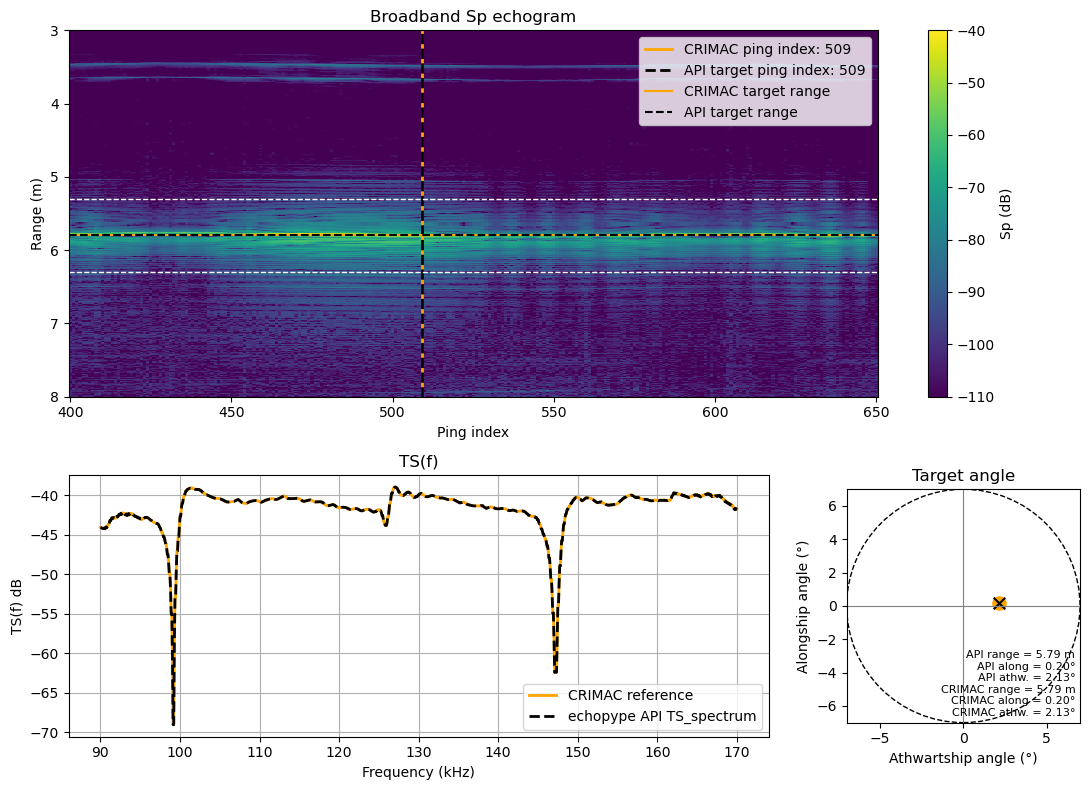

In [63]:
# --- Choose API target to inspect ---
target_to_plot = 509

ch = tsf_channel

api_color = "black"
crimac_color = "orange"
range_color = api_color

# CRIMAC reference target
crimac_ping_idx = tsf_ping_index
crimac_range = r_t
crimac_theta = theta_t
crimac_phi = phi_t

f_crimac = ref_ts["f_m"]
ts_crimac = ref_ts["TS_m"]

# API target selection
ts_api_plot = (
    ds_TS_spectrum_fr["TS_spectrum"]
    .sel(channel=ch)
    .isel(target_id=target_to_plot)
)

api_ping_time = (
    ds_TS_spectrum_fr["ping_time"]
    .sel(channel=ch)
    .isel(target_id=target_to_plot)
    .values
)

f_api_plot = ds_TS_spectrum_fr["frequency"].values

target_range_plot = float(
    ds_TS_spectrum_fr["target_range"]
    .sel(channel=ch)
    .isel(target_id=target_to_plot)
)

theta_plot = float(
    ds_TS_spectrum_fr["angle_alongship"]
    .sel(channel=ch)
    .isel(target_id=target_to_plot)
)

phi_plot = float(
    ds_TS_spectrum_fr["angle_athwartship"]
    .sel(channel=ch)
    .isel(target_id=target_to_plot)
)

api_ping_idx_plot = int(
    np.argmin(
        np.abs(
            cal_obj.beam["ping_time"].values.astype("datetime64[ns]")
            - np.datetime64(api_ping_time, "ns")
        )
    )
)

print("target_to_plot:", target_to_plot)
print("api target_id:", ds_TS_spectrum_fr["target_id"].isel(target_id=target_to_plot).values)
print("api ping index:", api_ping_idx_plot)
print("api target range:", target_range_plot)
print("api theta/phi:", theta_plot, phi_plot)
print("CRIMAC ping index:", crimac_ping_idx)
print("CRIMAC range:", crimac_range)
print("CRIMAC theta/phi:", crimac_theta, crimac_phi)

# --- Echogram from public API Sp output ---
ping_start = 400
ping_end = 650

echogram_db = (
    ds_Sp["Sp"]
    .sel(channel=ch)
    .isel(ping_time=slice(ping_start, ping_end + 1))
    .transpose("range_sample", "ping_time")
)

r_plot = (
    cal_obj.range_meter
    .sel(channel=ch)
    .isel(ping_time=ping_start)
    .values
)

ping_no = np.arange(ping_start, ping_end + 1)
valid_r = np.isfinite(r_plot)

fig = plt.figure(figsize=(11, 8))
gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[3, 1],
    height_ratios=[1.4, 1],
)

ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

# --- Echogram ---
im = ax0.pcolormesh(
    ping_no,
    r_plot[valid_r],
    echogram_db.values[valid_r, :],
    shading="auto",
    vmin=-110,
    vmax=-40,
)

ax0.axvline(
    crimac_ping_idx,
    color=crimac_color,
    linewidth=2,
    label=f"CRIMAC ping index: {crimac_ping_idx}",
)

ax0.axvline(
    api_ping_idx_plot,
    color=api_color,
    linestyle="--",
    linewidth=2,
    label=f"API target ping index: {api_ping_idx_plot}",
)

ax0.axhline(5.3, color="white", linestyle="--", linewidth=1)
ax0.axhline(6.3, color="white", linestyle="--", linewidth=1)

ax0.axhline(
    crimac_range,
    color=crimac_color,
    linewidth=1.5,
    label="CRIMAC target range",
)

ax0.axhline(
    target_range_plot,
    color=range_color,
    linewidth=1.5,
    linestyle="--",
    label="API target range",
)

ax0.set_ylim(8, 3)
ax0.set_xlabel("Ping index")
ax0.set_ylabel("Range (m)")
ax0.set_title("Broadband Sp echogram")
ax0.legend(loc="upper right")

cbar = plt.colorbar(im, ax=ax0)
cbar.set_label("Sp (dB)")

# --- TS(f) ---
ax1.plot(
    f_crimac / 1000,
    ts_crimac,
    color=crimac_color,
    linewidth=2,
    label="CRIMAC reference",
)

ax1.plot(
    f_api_plot / 1000,
    ts_api_plot.values,
    color=api_color,
    linestyle="--",
    linewidth=2,
    label="echopype API TS_spectrum",
)

ax1.set_xlabel("Frequency (kHz)")
ax1.set_ylabel("TS(f) dB")
ax1.set_title("TS(f)")
ax1.grid(True)
ax1.legend()

# --- Circular angle plot ---
beam_limit = 7.0
circle = plt.Circle((0, 0), beam_limit, fill=False, linestyle="--")
ax2.add_patch(circle)

ax2.axhline(0, color="grey", linewidth=0.8)
ax2.axvline(0, color="grey", linewidth=0.8)

ax2.scatter(
    crimac_phi,
    crimac_theta,
    s=90,
    color=crimac_color,
    label="CRIMAC",
)

ax2.scatter(
    phi_plot,
    theta_plot,
    s=70,
    color=api_color,
    marker="x",
    label="API",
)

ax2.set_xlim(-beam_limit, beam_limit)
ax2.set_ylim(-beam_limit, beam_limit)
ax2.set_aspect("equal", adjustable="box")

ax2.set_xlabel("Athwartship angle (°)")
ax2.set_ylabel("Alongship angle (°)")
ax2.set_title("Target angle")

ax2.text(
    0.98,
    0.02,
    f"API range = {target_range_plot:.2f} m\n"
    f"API along = {theta_plot:.2f}°\n"
    f"API athw. = {phi_plot:.2f}°\n"
    f"CRIMAC range = {crimac_range:.2f} m\n"
    f"CRIMAC along = {crimac_theta:.2f}°\n"
    f"CRIMAC athw. = {crimac_phi:.2f}°",
    transform=ax2.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
)

plt.tight_layout()
plt.show()

Print of import and their version

In [64]:
import sys

print("Python:", sys.version.split()[0])
print("echopype:", ep.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("xarray:", xr.__version__)
print("matplotlib:", plt.matplotlib.__version__)

Python: 3.12.13
echopype: 0.11.2.dev22+gc1a2a5660
numpy: 2.4.4
pandas: 3.0.2
xarray: 2026.4.0
matplotlib: 3.10.9


End of notebook.